# Лабораторная работа №1

### Искусственный нейрон и многослойная сеть для классификации Iris

**Цель работы:**
Самостоятельно реализовать искусственный нейрон с сигмоидальной функцией активации, построить на его основе многослойную сеть, реализовать градиентный спуск и обратное распространение ошибки.

**Задачи:**
1. Решить задачу бинарной классификации датасета Iris одним нейроном.
2. Решить задачу бинарной классификации датасета Iris нейросетью с двумя скрытыми слоями по 10 нейронов.
3. Визуализировать разделяющие линии для обеих моделей (на двух признаках).
4. Сравнить метрики классификации.

## 1. Импорт библиотек

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from typing import Optional, List, Tuple, Any

## 2. Функции активации и их производные

In [2]:
def sigmoid(z: np.ndarray) -> np.ndarray:
    # Сигмоидальная функция активации. Ограничивает входные значения для избежания переполнения.
    clipped_z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-clipped_z))

def sigmoid_derivative(a: np.ndarray) -> np.ndarray:
    # Производная сигмоидальной функции. a - выход сигмоиды (sigmoid(z)).
    return a * (1.0 - a)

## 3. Реализация одиночного нейрона

In [3]:
class SingleNeuron:
    # Одиночный искусственный нейрон с сигмоидальной активацией.
    # Реализует градиентный спуск для бинарной классификации.
    
    def __init__(self, n_features: int, learning_rate: float = 0.1, n_epochs: int = 1000, random_seed: int = 42) -> None:
        # Инициализация нейрона.
        rng = np.random.default_rng(random_seed)
        self.weights = rng.normal(0, 0.01, n_features)  # веса
        self.bias = 0.0                                 # смещение
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.loss_history: List[float] = []
        
    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        # Вычисление вероятности принадлежности к классу 1.
        linear_output = X @ self.weights + self.bias
        return sigmoid(linear_output)
    
    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        # Бинарное предсказание (0 или 1).
        return (self.predict_proba(X) >= threshold).astype(int)
    
    def _compute_loss(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        # Вычисление бинарной кросс-энтропии. Добавляется малая константа для численной стабильности.
        eps = 1e-9
        return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))
    
    def fit(self, X: np.ndarray, y: np.ndarray) -> 'SingleNeuron':
        # Обучение нейрона с помощью градиентного спуска.
        n_samples = len(y)
        
        for epoch in range(self.n_epochs):
            # Прямой проход (forward pass)
            y_pred = self.predict_proba(X)
            
            # Вычисление ошибки
            loss = self._compute_loss(y, y_pred)
            self.loss_history.append(loss)
            
            # Обратное распространение (градиенты)
            error = (y_pred - y) / n_samples
            
            # Обновление параметров
            self.weights -= self.learning_rate * (X.T @ error)
            self.bias -= self.learning_rate * error.sum()
            
        return self

## 4. Реализация многослойной нейронной сети

In [4]:
class MultiLayerNetwork:
    # Многослойная нейронная сеть с сигмоидальными нейронами.
    # Реализует обратное распространение ошибки.
    
    def __init__(self, layer_sizes: List[int], learning_rate: float = 0.05, n_epochs: int = 2000, random_seed: int = 42) -> None:
        # Инициализация сети.
        self.layer_sizes = layer_sizes
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.loss_history: List[float] = []
        self._initialize_weights(random_seed)
    
    def _initialize_weights(self, random_seed: int = 42) -> None:
        # Инициализация весов с использованием Xavier/Glorot инициализации.
        rng = np.random.default_rng(random_seed)
        self.weights: List[np.ndarray] = []  # веса между слоями
        self.biases: List[np.ndarray] = []   # смещения для слоев
        
        for i in range(len(self.layer_sizes) - 1):
            fan_in = self.layer_sizes[i]
            fan_out = self.layer_sizes[i + 1]
            # Xavier инициализация для сигмоиды
            scale = np.sqrt(2.0 / (fan_in + fan_out))
            self.weights.append(rng.normal(0, scale, (fan_in, fan_out)))
            self.biases.append(np.zeros(fan_out))
    
    def _forward_pass(self, X: np.ndarray) -> List[np.ndarray]:
        # Прямой проход по сети. Возвращает активации всех слоев (включая входной).
        activations = [X]
        current_activation = X
        
        for W, b in zip(self.weights, self.biases):
            linear_output = current_activation @ W + b
            current_activation = sigmoid(linear_output)
            activations.append(current_activation)
            
        return activations
    
    def _backward_pass(self, activations: List[np.ndarray], y_true: np.ndarray) -> Tuple[List[np.ndarray], List[np.ndarray]]:
        # Обратный проход (backpropagation). Вычисляет градиенты для весов и смещений.
        n_samples = len(y_true)
        grad_weights = [None] * len(self.weights)
        grad_biases = [None] * len(self.biases)
        
        # Ошибка на выходном слое
        delta = (activations[-1] - y_true.reshape(-1, 1)) / n_samples
        
        # Проход по слоям в обратном порядке
        for i in reversed(range(len(self.weights))):
            grad_weights[i] = activations[i].T @ delta
            grad_biases[i] = delta.sum(axis=0)
            
            # Ошибка для предыдущего слоя (если есть)
            if i > 0:
                delta = (delta @ self.weights[i].T) * sigmoid_derivative(activations[i])
                
        return grad_weights, grad_biases
    
    def _compute_loss(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        # Бинарная кросс-энтропия.
        eps = 1e-9
        return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))
    
    def fit(self, X: np.ndarray, y: np.ndarray) -> 'MultiLayerNetwork':
        # Обучение сети с помощью градиентного спуска.
        for epoch in range(self.n_epochs):
            # Прямой проход
            activations = self._forward_pass(X)
            y_pred = activations[-1].ravel()
            
            # Вычисление ошибки
            loss = self._compute_loss(y, y_pred)
            self.loss_history.append(loss)
            
            # Обратный проход и обновление параметров
            grad_w, grad_b = self._backward_pass(activations, y)
            
            for i in range(len(self.weights)):
                self.weights[i] -= self.learning_rate * grad_w[i]
                self.biases[i] -= self.learning_rate * grad_b[i]
                
        return self
    
    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        # Вероятность принадлежности к классу 1.
        return self._forward_pass(X)[-1].ravel()
    
    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        # Бинарное предсказание.
        return (self.predict_proba(X) >= threshold).astype(int)

## 5. Загрузка и подготовка данных

In [5]:
# Загрузка датасета Iris
iris = load_iris()
X_full = iris.data
y_binary = (iris.target != 0).astype(float)  # класс 0: setosa, класс 1: versicolor + virginica

# Для визуализации будем использовать только первые два признака
FEATURE_X, FEATURE_Y = 0, 1  # sepal length, sepal width
X_2features = X_full[:, [FEATURE_X, FEATURE_Y]]
X_4features = X_full  # все 4 признака

# Нормализация данных
scaler_2f = StandardScaler()
scaler_4f = StandardScaler()
X_2features_scaled = scaler_2f.fit_transform(X_2features)
X_4features_scaled = scaler_4f.fit_transform(X_4features)

# Разделение на обучающую и тестовую выборки (75% / 25%)
X_2f_train, X_2f_test, y_train, y_test = train_test_split(
    X_2features_scaled, y_binary, test_size=0.25, random_state=42
)
X_4f_train, X_4f_test, _, _ = train_test_split(
    X_4features_scaled, y_binary, test_size=0.25, random_state=42
)

print(f"Размер обучающей выборки: {len(y_train)}")
print(f"Размер тестовой выборки: {len(y_test)}")
print(f"Количество признаков (модель 1): {X_4features.shape[1]}")
print(f"Количество признаков (модель 2): {X_2features.shape[1]}")

Размер обучающей выборки: 112
Размер тестовой выборки: 38
Количество признаков (модель 1): 4
Количество признаков (модель 2): 2


## 6. Обучение и оценка моделей (на всех 4 признаках)

In [6]:
# Модель 1: Одиночный нейрон
print("=" * 60)
print("Модель 1: Одиночный нейрон (4 входных признака)")
print("=" * 60)

neuron_model = SingleNeuron(
    n_features=4, 
    learning_rate=0.5, 
    n_epochs=2000,
    random_seed=42
)
neuron_model.fit(X_4f_train, y_train)
y_pred_neuron = neuron_model.predict(X_4f_test)

print("\nОтчет классификации для одиночного нейрона:")
print(classification_report(y_test, y_pred_neuron, target_names=["setosa", "non-setosa"]))

Модель 1: Одиночный нейрон (4 входных признака)

Отчет классификации для одиночного нейрона:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  non-setosa       1.00      1.00      1.00        23

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [7]:
# Модель 2: Многослойная сеть (4 -> 10 -> 10 -> 1)
print("=" * 60)
print("Модель 2: Нейросеть 4->10->10->1 (2 скрытых слоя по 10 нейронов)")
print("=" * 60)

nn_model = MultiLayerNetwork(
    layer_sizes=[4, 10, 10, 1],
    learning_rate=0.1,
    n_epochs=3000,
    random_seed=42
)
nn_model.fit(X_4f_train, y_train)
y_pred_nn = nn_model.predict(X_4f_test)

print("\nОтчет классификации для нейросети:")
print(classification_report(y_test, y_pred_nn, target_names=["setosa", "non-setosa"]))


Модель 2: Нейросеть 4->10->10->1 (2 скрытых слоя по 10 нейронов)

Отчет классификации для нейросети:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  non-setosa       1.00      1.00      1.00        23

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [8]:
# Сравнение метрик
print("\n" + "=" * 60)
print("Сравнение метрик классификации")
print("=" * 60)

metrics = {
    "Accuracy": accuracy_score,
    "Precision": lambda y, y_pred: precision_score(y, y_pred, zero_division=0),
    "Recall": lambda y, y_pred: recall_score(y, y_pred, zero_division=0),
    "F1-score": lambda y, y_pred: f1_score(y, y_pred, zero_division=0)
}

print(f"{'Метрика':<15} {'Одиночный нейрон':>20} {'Нейросеть (2 слоя)':>20}")
print("-" * 55)

for metric_name, metric_fn in metrics.items():
    value_neuron = metric_fn(y_test, y_pred_neuron)
    value_nn = metric_fn(y_test, y_pred_nn)
    print(f"{metric_name:<15} {value_neuron:>20.4f} {value_nn:>20.4f}")


Сравнение метрик классификации
Метрика             Одиночный нейрон   Нейросеть (2 слоя)
-------------------------------------------------------
Accuracy                      1.0000               1.0000
Precision                     1.0000               1.0000
Recall                        1.0000               1.0000
F1-score                      1.0000               1.0000


## 7. Визуализация разделяющих линий (на 2 признаках)

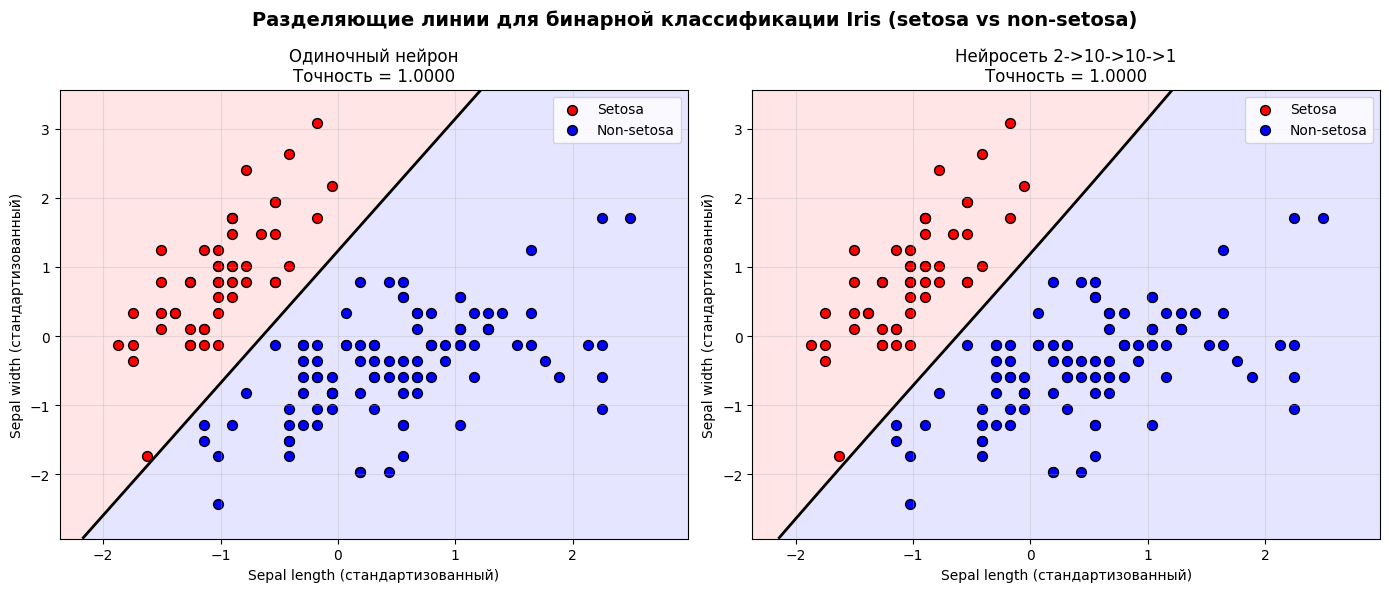

In [9]:
# Обучение моделей на двух признаках для визуализации
neuron_2f = SingleNeuron(n_features=2, learning_rate=0.5, n_epochs=2000, random_seed=42)
neuron_2f.fit(X_2f_train, y_train)

nn_2f = MultiLayerNetwork(layer_sizes=[2, 10, 10, 1], learning_rate=0.1, n_epochs=3000, random_seed=42)
nn_2f.fit(X_2f_train, y_train)

# Создание сетки для визуализации
h = 0.05  # шаг сетки
x_min, x_max = X_2features_scaled[:, 0].min() - 0.5, X_2features_scaled[:, 0].max() + 0.5
y_min, y_max = X_2features_scaled[:, 1].min() - 0.5, X_2features_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Предсказания для сетки
Z_neuron = neuron_2f.predict_proba(grid_points).reshape(xx.shape)
Z_nn = nn_2f.predict_proba(grid_points).reshape(xx.shape)

# Построение графиков
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Разделяющие линии для бинарной классификации Iris (setosa vs non-setosa)', 
             fontsize=14, fontweight='bold')

# Цвета
colors_regions = ['#FFCCCC', '#CCCCFF']  # розовый для setosa, сиреневый для non-setosa
colors_points = {0: 'red', 1: 'blue'}
labels = {0: 'Setosa', 1: 'Non-setosa'}

# График 1: Одиночный нейрон
ax1 = axes[0]
contourf1 = ax1.contourf(xx, yy, Z_neuron, levels=[0, 0.5, 1], colors=colors_regions, alpha=0.5)
contour1 = ax1.contour(xx, yy, Z_neuron, levels=[0.5], colors='black', linewidths=2)

for class_label, color in colors_points.items():
    mask = y_binary == class_label
    ax1.scatter(X_2features_scaled[mask, 0], X_2features_scaled[mask, 1], 
                c=color, edgecolors='black', s=50, label=labels[class_label])

acc_neuron = accuracy_score(y_test, neuron_2f.predict(X_2f_test))
ax1.set_title(f'Одиночный нейрон\nТочность = {acc_neuron:.4f}', fontsize=12)
ax1.set_xlabel('Sepal length (стандартизованный)')
ax1.set_ylabel('Sepal width (стандартизованный)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# График 2: Нейросеть
ax2 = axes[1]
contourf2 = ax2.contourf(xx, yy, Z_nn, levels=[0, 0.5, 1], colors=colors_regions, alpha=0.5)
contour2 = ax2.contour(xx, yy, Z_nn, levels=[0.5], colors='black', linewidths=2)

for class_label, color in colors_points.items():
    mask = y_binary == class_label
    ax2.scatter(X_2features_scaled[mask, 0], X_2features_scaled[mask, 1], 
                c=color, edgecolors='black', s=50, label=labels[class_label])

acc_nn = accuracy_score(y_test, nn_2f.predict(X_2f_test))
ax2.set_title(f'Нейросеть 2->10->10->1\nТочность = {acc_nn:.4f}', fontsize=12)
ax2.set_xlabel('Sepal length (стандартизованный)')
ax2.set_ylabel('Sepal width (стандартизованный)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lab1_decision_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Графики обучения (кривые потерь)


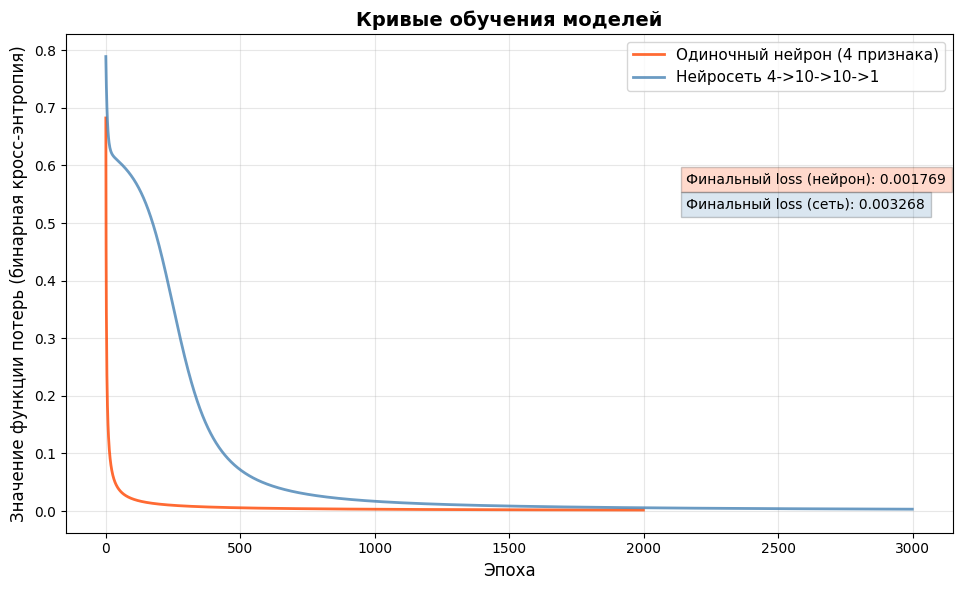

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(neuron_model.loss_history, label='Одиночный нейрон (4 признака)', 
        color='orangered', linewidth=2, alpha=0.8)
ax.plot(nn_model.loss_history, label='Нейросеть 4->10->10->1', 
        color='steelblue', linewidth=2, alpha=0.8)

ax.set_xlabel('Эпоха', fontsize=12)
ax.set_ylabel('Значение функции потерь (бинарная кросс-энтропия)', fontsize=12)
ax.set_title('Кривые обучения моделей', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Добавление финальных значений потерь
final_loss_neuron = neuron_model.loss_history[-1]
final_loss_nn = nn_model.loss_history[-1]
ax.text(0.7, 0.7, f'Финальный loss (нейрон): {final_loss_neuron:.6f}', 
        transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='orangered', alpha=0.2))
ax.text(0.7, 0.65, f'Финальный loss (сеть): {final_loss_nn:.6f}', 
        transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='steelblue', alpha=0.2))

plt.tight_layout()
plt.savefig('lab1_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Выводы
 
На основе проведенных экспериментов можно сделать следующие выводы:

1. **Одиночный нейрон** успешно справляется с задачей бинарной классификации Iris (setosa против всех остальных), достигая высоких показателей точности.
 
2. **Многослойная сеть** с двумя скрытыми слоями по 10 нейронов показывает сравнимые результаты, что объясняется тем, что данная задача является линейно разделимой.
 
3. **Визуализация разделяющих линий** демонстрирует, что обе модели формируют линейную границу решения, что соответствует теоретическим ожиданиям.

4. **Кривые потерь** показывают, что обе модели успешно сходятся, причем нейросеть требует больше эпох для стабилизации.
 
5. **Результаты эксперимента** подтверждают, что даже простой нейрон способен решать задачи бинарной классификации на реальных данных, а многослойная архитектура обеспечивает дополнительную гибкость при сохранении качества.